In [1]:
# ============================================================
# NOTEBOOK 3: DIAGRAMAS DE FLUJO
# TFG - Juan Diez de Rivera de Solís
# ============================================================

# Instalamos matplotlib y graphviz para diagramas
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', 'graphviz', '--quiet'])

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


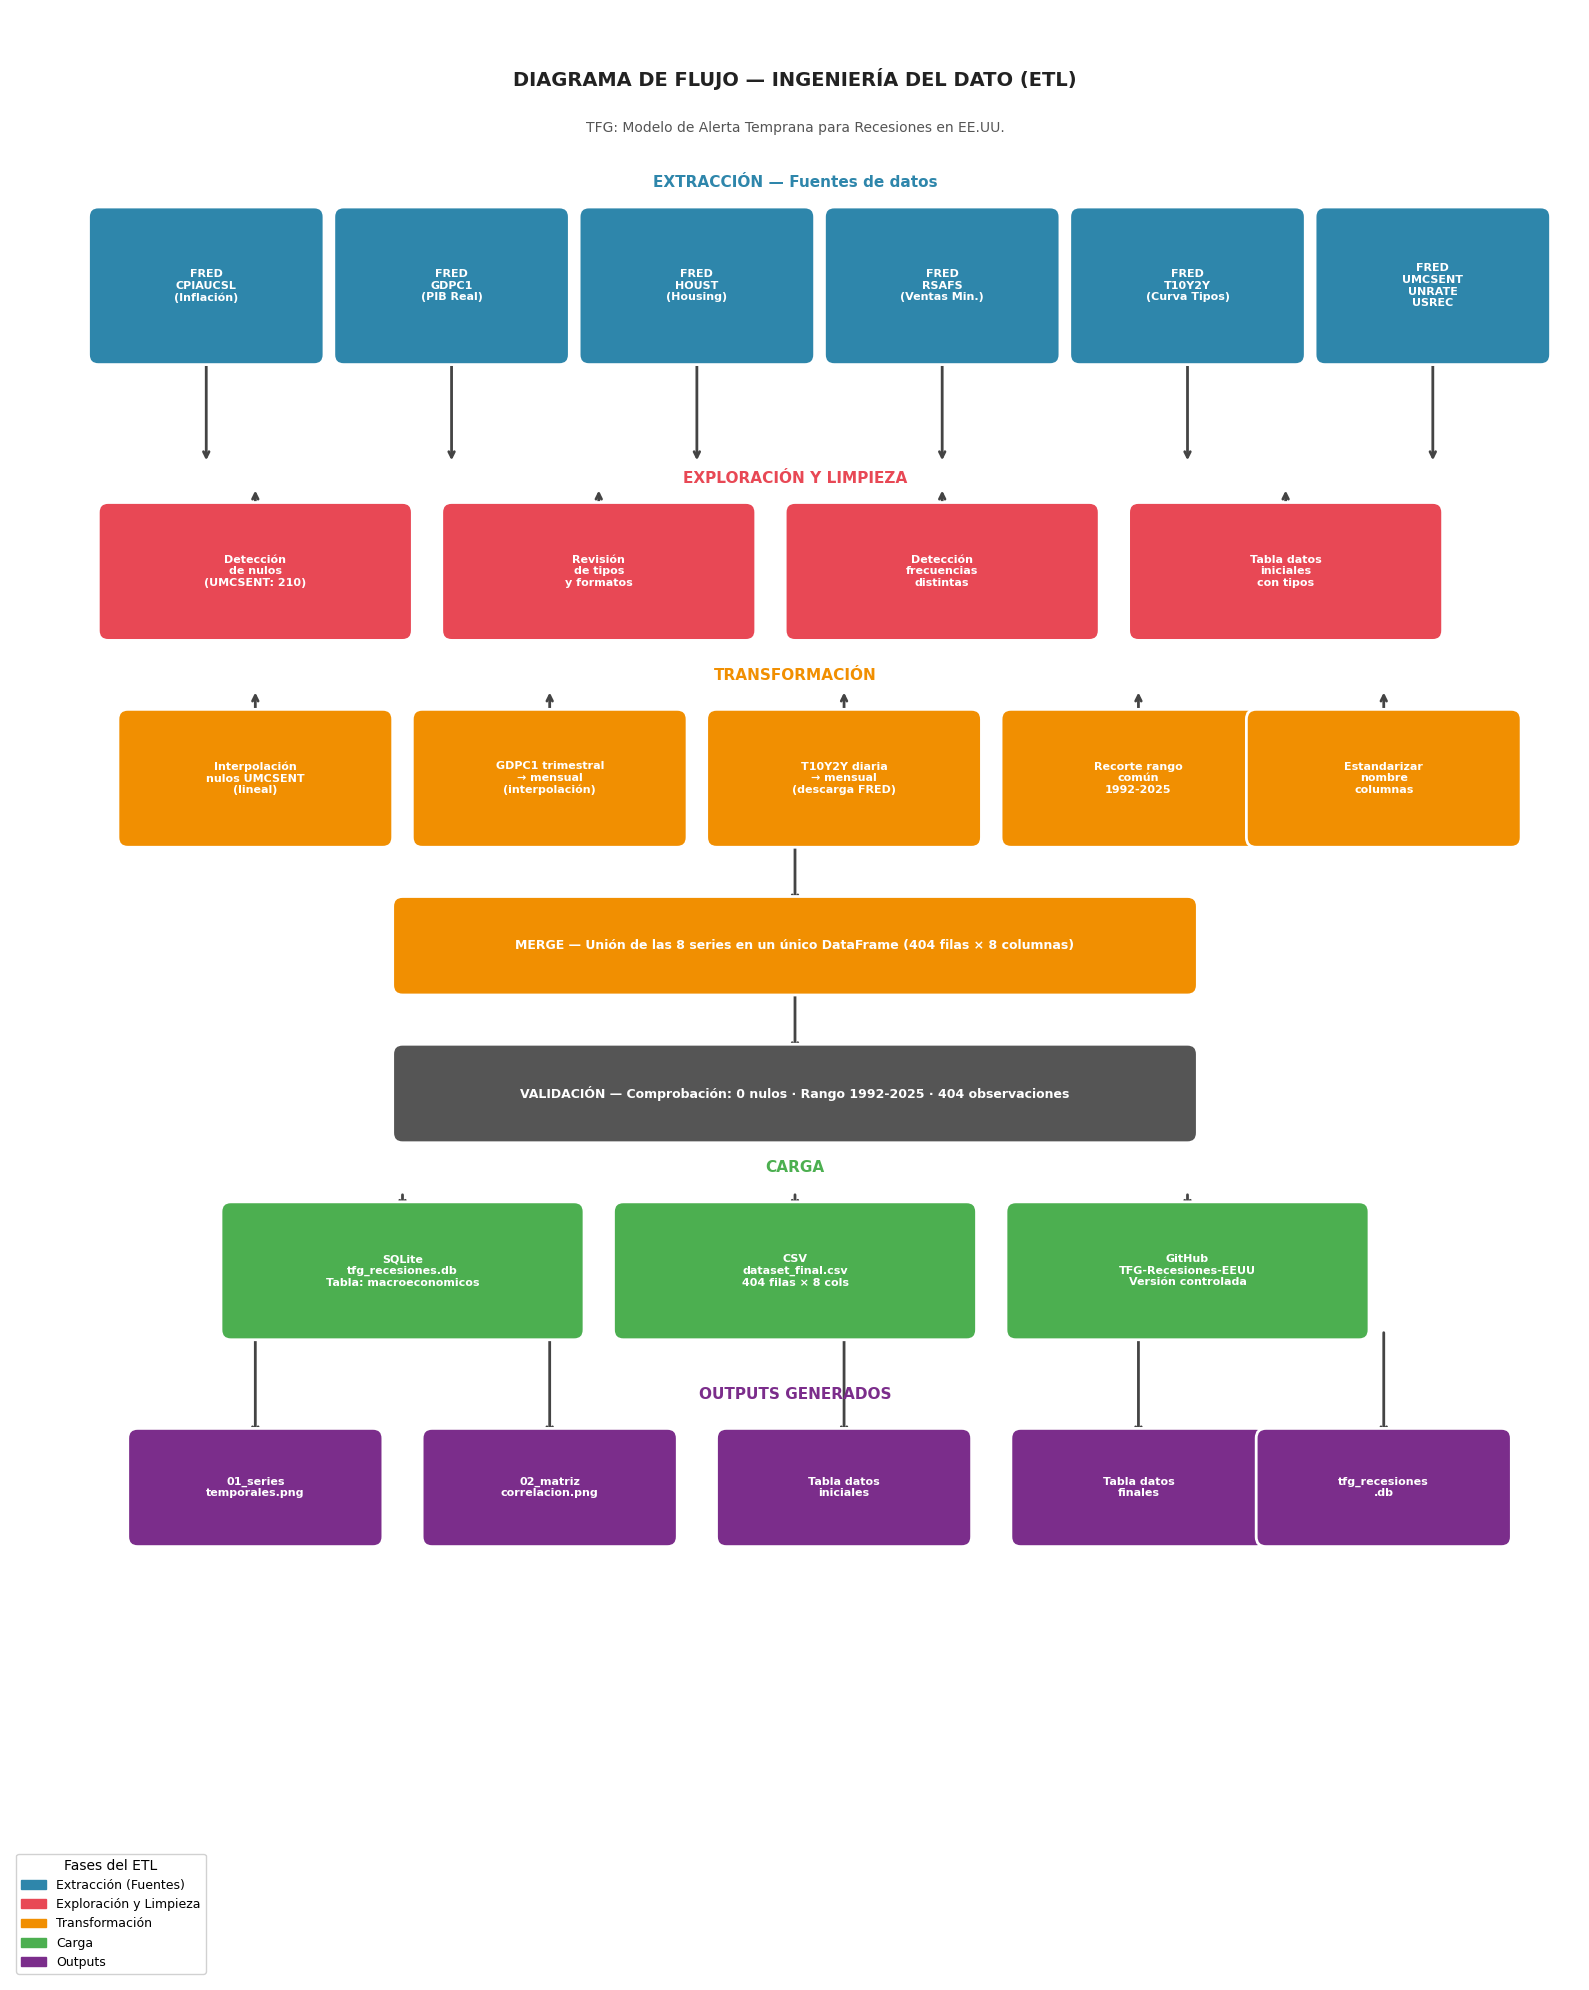

✅ Diagrama ETL guardado como 12_diagrama_ETL.png


In [2]:
# ============================================================
# CELDA 2: DIAGRAMA DE FLUJO - INGENIERÍA DEL DATO (ETL)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(16, 20))
ax.set_xlim(0, 16)
ax.set_ylim(0, 20)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, fontsize=9, radius=0.3):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=f"round,pad=0.1",
                          facecolor=color, edgecolor='white',
                          linewidth=2, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', zorder=4, wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#444444',
                               lw=2), zorder=2)

# Colores
C_SOURCE  = '#2E86AB'  # Azul — fuentes
C_ETL     = '#E84855'  # Rojo — extracción
C_TRANS   = '#F18F01'  # Naranja — transformación
C_LOAD    = '#4CAF50'  # Verde — carga
C_OUTPUT  = '#7B2D8B'  # Morado — output

# --- TÍTULO ---
ax.text(8, 19.3, 'DIAGRAMA DE FLUJO — INGENIERÍA DEL DATO (ETL)',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#222222')
ax.text(8, 18.8, 'TFG: Modelo de Alerta Temprana para Recesiones en EE.UU.',
        ha='center', va='center', fontsize=10, color='#555555')

# --- FUENTES DE DATOS ---
ax.text(8, 18.2, 'EXTRACCIÓN — Fuentes de datos', ha='center',
        fontsize=11, fontweight='bold', color=C_SOURCE)

fuentes = [
    (2.0,  17.2, 'FRED\nCPIAUCSL\n(Inflación)'),
    (4.5,  17.2, 'FRED\nGDPC1\n(PIB Real)'),
    (7.0,  17.2, 'FRED\nHOUST\n(Housing)'),
    (9.5,  17.2, 'FRED\nRSAFS\n(Ventas Min.)'),
    (12.0, 17.2, 'FRED\nT10Y2Y\n(Curva Tipos)'),
    (14.5, 17.2, 'FRED\nUMCSENT\nUNRATE\nUSREC'),
]
for x, y, t in fuentes:
    draw_box(ax, x, y, 2.2, 1.4, t, C_SOURCE, fontsize=8)

# Flechas fuentes → limpieza
for x, y, _ in fuentes:
    draw_arrow(ax, x, y - 0.7, x, 15.4)

# --- EXPLORACIÓN Y LIMPIEZA ---
ax.text(8, 15.2, 'EXPLORACIÓN Y LIMPIEZA', ha='center',
        fontsize=11, fontweight='bold', color=C_ETL)

limpiezas = [
    (2.5,  14.3, 'Detección\nde nulos\n(UMCSENT: 210)'),
    (6.0,  14.3, 'Revisión\nde tipos\ny formatos'),
    (9.5,  14.3, 'Detección\nfrecuencias\ndistintas'),
    (13.0, 14.3, 'Tabla datos\niniciales\ncon tipos'),
]
for x, y, t in limpiezas:
    draw_box(ax, x, y, 3.0, 1.2, t, C_ETL, fontsize=8)
    draw_arrow(ax, x, y + 0.6, x, y + 0.85)

# --- TRANSFORMACIÓN ---
ax.text(8, 13.2, 'TRANSFORMACIÓN', ha='center',
        fontsize=11, fontweight='bold', color=C_TRANS)

trans = [
    (2.5,  12.2, 'Interpolación\nnulos UMCSENT\n(lineal)'),
    (5.5,  12.2, 'GDPC1 trimestral\n→ mensual\n(interpolación)'),
    (8.5,  12.2, 'T10Y2Y diaria\n→ mensual\n(descarga FRED)'),
    (11.5, 12.2, 'Recorte rango\ncomún\n1992-2025'),
    (14.0, 12.2, 'Estandarizar\nnombre\ncolumnas'),
]
for x, y, t in trans:
    draw_box(ax, x, y, 2.6, 1.2, t, C_TRANS, fontsize=8)
    draw_arrow(ax, x, y + 0.6, x, y + 0.9)

# --- MERGE ---
draw_arrow(ax, 8, 11.6, 8, 10.9)
draw_box(ax, 8, 10.5, 8, 0.8,
         'MERGE — Unión de las 8 series en un único DataFrame (404 filas × 8 columnas)',
         C_TRANS, fontsize=9)

# --- VALIDACIÓN ---
draw_arrow(ax, 8, 10.1, 8, 9.4)
draw_box(ax, 8, 9.0, 8, 0.8,
         'VALIDACIÓN — Comprobación: 0 nulos · Rango 1992-2025 · 404 observaciones',
         '#555555', fontsize=9)

# --- CARGA ---
ax.text(8, 8.2, 'CARGA', ha='center',
        fontsize=11, fontweight='bold', color=C_LOAD)

cargas = [
    (4.0, 7.2, 'SQLite\ntfg_recesiones.db\nTabla: macroeconomicos'),
    (8.0, 7.2, 'CSV\ndataset_final.csv\n404 filas × 8 cols'),
    (12.0, 7.2, 'GitHub\nTFG-Recesiones-EEUU\nVersión controlada'),
]
for x, y, t in cargas:
    draw_box(ax, x, y, 3.5, 1.2, t, C_LOAD, fontsize=8)
    draw_arrow(ax, x, 8.0, x, y + 0.6)

# --- OUTPUTS ---
ax.text(8, 5.9, 'OUTPUTS GENERADOS', ha='center',
        fontsize=11, fontweight='bold', color=C_OUTPUT)

outputs = [
    (2.5,  5.0, '01_series\ntemporales.png'),
    (5.5,  5.0, '02_matriz\ncorrelacion.png'),
    (8.5,  5.0, 'Tabla datos\niniciales'),
    (11.5, 5.0, 'Tabla datos\nfinales'),
    (14.0, 5.0, 'tfg_recesiones\n.db'),
]
for x, y, t in outputs:
    draw_box(ax, x, y, 2.4, 1.0, t, C_OUTPUT, fontsize=8)
    draw_arrow(ax, x, 6.6, x, y + 0.5)

# Leyenda
legend_items = [
    mpatches.Patch(color=C_SOURCE, label='Extracción (Fuentes)'),
    mpatches.Patch(color=C_ETL,    label='Exploración y Limpieza'),
    mpatches.Patch(color=C_TRANS,  label='Transformación'),
    mpatches.Patch(color=C_LOAD,   label='Carga'),
    mpatches.Patch(color=C_OUTPUT, label='Outputs'),
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=9, framealpha=0.9, title='Fases del ETL')

plt.tight_layout()
plt.savefig("12_diagrama_ETL.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diagrama ETL guardado como 12_diagrama_ETL.png")

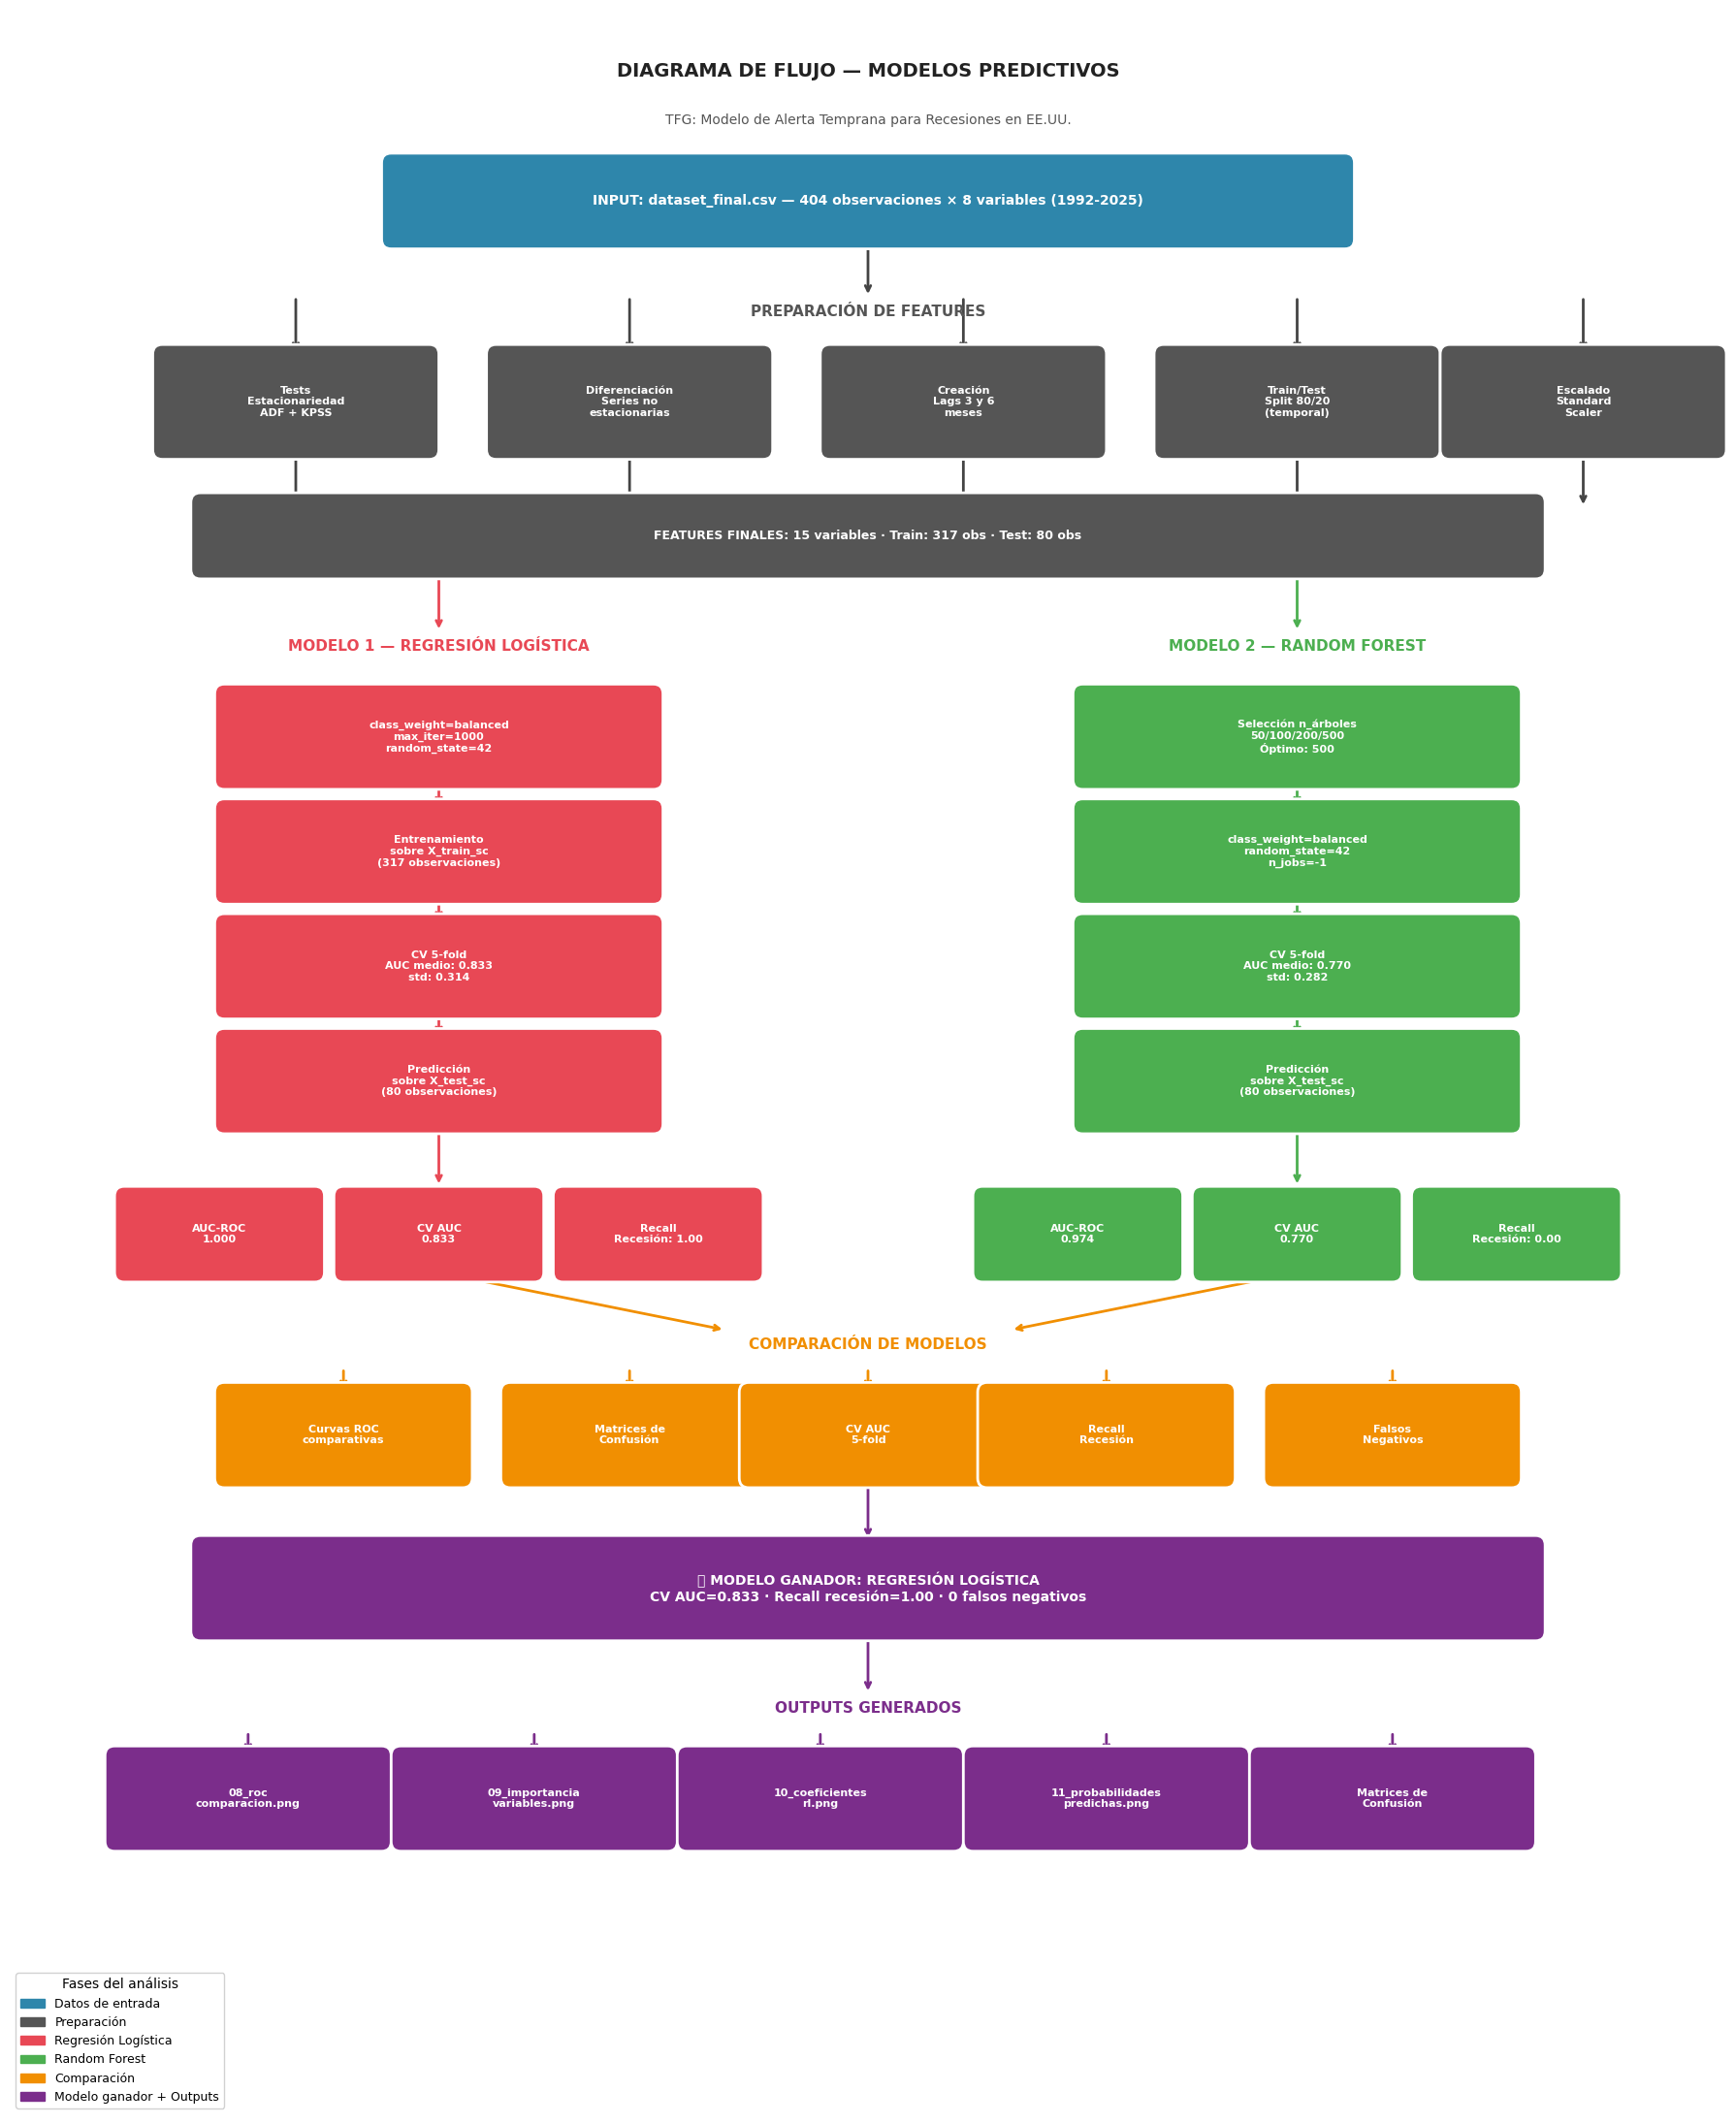

✅ Diagrama de modelos guardado como 13_diagrama_modelos.png


In [3]:
# ============================================================
# CELDA 3: DIAGRAMA DE FLUJO - MODELOS PREDICTIVOS
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(18, 22))
ax.set_xlim(0, 18)
ax.set_ylim(0, 22)
ax.axis('off')

# Colores
C_DATA    = '#2E86AB'  # Azul — datos entrada
C_PREP    = '#555555'  # Gris — preparación
C_RL      = '#E84855'  # Rojo — Regresión Logística
C_RF      = '#4CAF50'  # Verde — Random Forest
C_COMP    = '#F18F01'  # Naranja — comparación
C_WIN     = '#7B2D8B'  # Morado — modelo ganador

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white',
                          linewidth=2, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', zorder=4, multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, color='#444444'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2), zorder=2)

# TÍTULO
ax.text(9, 21.3, 'DIAGRAMA DE FLUJO — MODELOS PREDICTIVOS',
        ha='center', fontsize=14, fontweight='bold', color='#222222')
ax.text(9, 20.8, 'TFG: Modelo de Alerta Temprana para Recesiones en EE.UU.',
        ha='center', fontsize=10, color='#555555')

# ENTRADA
draw_box(ax, 9, 20.0, 10, 0.8,
         'INPUT: dataset_final.csv — 404 observaciones × 8 variables (1992-2025)',
         C_DATA, fontsize=10)
draw_arrow(ax, 9, 19.6, 9, 19.0)

# PREPARACIÓN
ax.text(9, 18.8, 'PREPARACIÓN DE FEATURES', ha='center',
        fontsize=11, fontweight='bold', color=C_PREP)

preps = [
    (3.0,  17.9, 'Tests\nEstacionariedad\nADF + KPSS'),
    (6.5,  17.9, 'Diferenciación\nSeries no\nestacionarias'),
    (10.0, 17.9, 'Creación\nLags 3 y 6\nmeses'),
    (13.5, 17.9, 'Train/Test\nSplit 80/20\n(temporal)'),
    (16.5, 17.9, 'Escalado\nStandard\nScaler'),
]
for x, y, t in preps:
    draw_box(ax, x, y, 2.8, 1.0, t, C_PREP, fontsize=8)
    draw_arrow(ax, x, 19.0, x, y + 0.5)

# Línea hacia modelos
for x, _, _ in preps:
    draw_arrow(ax, x, 17.4, x, 16.8)

draw_box(ax, 9, 16.5, 14, 0.7,
         'FEATURES FINALES: 15 variables · Train: 317 obs · Test: 80 obs',
         C_PREP, fontsize=9)

# DIVISIÓN EN DOS MODELOS
draw_arrow(ax, 4.5, 16.15, 4.5, 15.5, color=C_RL)
draw_arrow(ax, 13.5, 16.15, 13.5, 15.5, color=C_RF)

# --- MODELO 1: REGRESIÓN LOGÍSTICA (izquierda) ---
ax.text(4.5, 15.3, 'MODELO 1 — REGRESIÓN LOGÍSTICA',
        ha='center', fontsize=11, fontweight='bold', color=C_RL)

rl_steps = [
    (4.5, 14.4, 'class_weight=balanced\nmax_iter=1000\nrandom_state=42'),
    (4.5, 13.2, 'Entrenamiento\nsobre X_train_sc\n(317 observaciones)'),
    (4.5, 12.0, 'CV 5-fold\nAUC medio: 0.833\nstd: 0.314'),
    (4.5, 10.8, 'Predicción\nsobre X_test_sc\n(80 observaciones)'),
]
for i, (x, y, t) in enumerate(rl_steps):
    draw_box(ax, x, y, 4.5, 0.9, t, C_RL, fontsize=8)
    if i < len(rl_steps)-1:
        draw_arrow(ax, x, y-0.45, x, rl_steps[i+1][1]+0.45, color=C_RL)

# Métricas RL
draw_arrow(ax, 4.5, 10.35, 4.5, 9.7, color=C_RL)
metricas_rl = [
    (2.2, 9.2, 'AUC-ROC\n1.000'),
    (4.5, 9.2, 'CV AUC\n0.833'),
    (6.8, 9.2, 'Recall\nRecesión: 1.00'),
]
for x, y, t in metricas_rl:
    draw_box(ax, x, y, 2.0, 0.8, t, C_RL, fontsize=8)

# --- MODELO 2: RANDOM FOREST (derecha) ---
ax.text(13.5, 15.3, 'MODELO 2 — RANDOM FOREST',
        ha='center', fontsize=11, fontweight='bold', color=C_RF)

rf_steps = [
    (13.5, 14.4, 'Selección n_árboles\n50/100/200/500\nÓptimo: 500'),
    (13.5, 13.2, 'class_weight=balanced\nrandom_state=42\nn_jobs=-1'),
    (13.5, 12.0, 'CV 5-fold\nAUC medio: 0.770\nstd: 0.282'),
    (13.5, 10.8, 'Predicción\nsobre X_test_sc\n(80 observaciones)'),
]
for i, (x, y, t) in enumerate(rf_steps):
    draw_box(ax, x, y, 4.5, 0.9, t, C_RF, fontsize=8)
    if i < len(rf_steps)-1:
        draw_arrow(ax, x, y-0.45, x, rf_steps[i+1][1]+0.45, color=C_RF)

# Métricas RF
draw_arrow(ax, 13.5, 10.35, 13.5, 9.7, color=C_RF)
metricas_rf = [
    (11.2, 9.2, 'AUC-ROC\n0.974'),
    (13.5, 9.2, 'CV AUC\n0.770'),
    (15.8, 9.2, 'Recall\nRecesión: 0.00'),
]
for x, y, t in metricas_rf:
    draw_box(ax, x, y, 2.0, 0.8, t, C_RF, fontsize=8)

# COMPARACIÓN
draw_arrow(ax, 4.5, 8.8, 7.5, 8.2, color=C_COMP)
draw_arrow(ax, 13.5, 8.8, 10.5, 8.2, color=C_COMP)

ax.text(9, 8.0, 'COMPARACIÓN DE MODELOS', ha='center',
        fontsize=11, fontweight='bold', color=C_COMP)

comp_items = [
    (3.5,  7.1, 'Curvas ROC\ncomparativas'),
    (6.5,  7.1, 'Matrices de\nConfusión'),
    (9.0,  7.1, 'CV AUC\n5-fold'),
    (11.5, 7.1, 'Recall\nRecesión'),
    (14.5, 7.1, 'Falsos\nNegativos'),
]
for x, y, t in comp_items:
    draw_box(ax, x, y, 2.5, 0.9, t, C_COMP, fontsize=8)
    draw_arrow(ax, x, 7.8, x, y+0.45, color=C_COMP)

# MODELO GANADOR
draw_arrow(ax, 9, 6.65, 9, 6.0, color=C_WIN)
draw_box(ax, 9, 5.5, 14, 0.9,
         '✅ MODELO GANADOR: REGRESIÓN LOGÍSTICA\nCV AUC=0.833 · Recall recesión=1.00 · 0 falsos negativos',
         C_WIN, fontsize=10)

# OUTPUTS
draw_arrow(ax, 9, 5.05, 9, 4.4, color=C_WIN)
ax.text(9, 4.2, 'OUTPUTS GENERADOS', ha='center',
        fontsize=11, fontweight='bold', color=C_WIN)

outputs = [
    (2.5,  3.3, '08_roc\ncomparacion.png'),
    (5.5,  3.3, '09_importancia\nvariables.png'),
    (8.5,  3.3, '10_coeficientes\nrl.png'),
    (11.5, 3.3, '11_probabilidades\npredichas.png'),
    (14.5, 3.3, 'Matrices de\nConfusión'),
]
for x, y, t in outputs:
    draw_box(ax, x, y, 2.8, 0.9, t, C_WIN, fontsize=8)
    draw_arrow(ax, x, 4.0, x, y+0.45, color=C_WIN)

# Leyenda
legend_items = [
    mpatches.Patch(color=C_DATA, label='Datos de entrada'),
    mpatches.Patch(color=C_PREP, label='Preparación'),
    mpatches.Patch(color=C_RL,   label='Regresión Logística'),
    mpatches.Patch(color=C_RF,   label='Random Forest'),
    mpatches.Patch(color=C_COMP, label='Comparación'),
    mpatches.Patch(color=C_WIN,  label='Modelo ganador + Outputs'),
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=9, framealpha=0.9, title='Fases del análisis')

plt.tight_layout()
plt.savefig("13_diagrama_modelos.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diagrama de modelos guardado como 13_diagrama_modelos.png")